# Employee Performance Index Prediction
## End-to-End Data Science Project
**Dataset:** INX Future Inc. Employee Performance (Kaggle)  
**Objective:** Predict employee performance rating and identify key factors  

---
### Table of Contents
1. Problem Definition
2. Dataset Overview & Loading
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Building
7. Model Evaluation & Tuning
8. Conclusion & Recommendations


---
## 1. Problem Definition

**Business Problem:**  
INX Future Inc. is a leading data analytics and automation solutions provider with over 15 years of global business presence. In recent years, employee performance indexes have been declining, becoming a growing concern for top management.

**Goals:**
- Analyze employee data to find core underlying causes of performance issues
- Build a machine learning model to predict employee performance rating
- Identify the top 3 factors affecting employee performance
- Provide actionable HR recommendations

**Problem Type:** Multi-class Classification  
**Target Variable:**  (1=Low, 2=Good, 3=Excellent, 4=Outstanding)


---
## 2. Import Libraries & Load Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
pd.set_option("display.max_columns", 50)

print("All libraries imported successfully!")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")


All libraries imported successfully!
Pandas: 2.3.3 | NumPy: 2.3.5


In [2]:
# Dataset: INX Future Inc. Employee Performance
# Source: https://www.kaggle.com/datasets/eshwarganta/employee-performance-analysis-inx-future-inc
# To use your downloaded file:
#   df = pd.read_csv("INX_Future_Inc_Employee_Performance_Data.csv")
#
# Synthetic dataset generated below for demonstration:

np.random.seed(42)
n = 1200

departments = ["Sales", "Human Resources", "Development", "Data Science", "Research & Development", "Finance"]
education_fields = ["Life Sciences", "Medical", "Marketing", "Technical Degree", "Other", "Human Resources"]
job_roles = ["Sales Executive", "Research Scientist", "Laboratory Technician",
             "Manufacturing Director", "Healthcare Representative", "Manager",
             "Sales Representative", "Research Director", "Human Resources"]

df = pd.DataFrame({
    "EmpNumber"                   : range(1001, 1001 + n),
    "Age"                         : np.random.randint(18, 60, n),
    "Gender"                      : np.random.choice(["Male", "Female"], n),
    "EducationBackground"         : np.random.choice(education_fields, n),
    "MaritalStatus"               : np.random.choice(["Single", "Married", "Divorced"], n),
    "EmpDepartment"               : np.random.choice(departments, n),
    "EmpJobRole"                  : np.random.choice(job_roles, n),
    "BusinessTravelFrequency"     : np.random.choice(["Travel_Rarely", "Travel_Frequently", "Non-Travel"], n),
    "DistanceFromHome"            : np.random.randint(1, 30, n),
    "EmpEducationLevel"           : np.random.randint(1, 6, n),
    "EmpEnvironmentSatisfaction"  : np.random.randint(1, 5, n),
    "EmpHourlyRate"               : np.random.randint(30, 100, n),
    "EmpJobInvolvement"           : np.random.randint(1, 5, n),
    "EmpJobLevel"                 : np.random.randint(1, 6, n),
    "EmpJobSatisfaction"          : np.random.randint(1, 5, n),
    "NumCompaniesWorked"          : np.random.randint(0, 10, n),
    "OverTime"                    : np.random.choice(["Yes", "No"], n),
    "EmpLastSalaryHikePercent"    : np.random.randint(10, 25, n),
    "EmpRelationshipSatisfaction" : np.random.randint(1, 5, n),
    "TotalWorkExperienceInYears"  : np.random.randint(0, 35, n),
    "TrainingTimesLastYear"       : np.random.randint(0, 7, n),
    "EmpWorkLifeBalance"          : np.random.randint(1, 5, n),
    "ExperienceYearsAtThisCompany": np.random.randint(0, 20, n),
    "ExperienceYearsInCurrentRole": np.random.randint(0, 15, n),
    "YearsSinceLastPromotion"     : np.random.randint(0, 15, n),
    "YearsWithCurrManager"        : np.random.randint(0, 15, n),
    "Attrition"                   : np.random.choice(["Yes", "No"], n, p=[0.16, 0.84]),
})

# Introduce missing values (realistic)
for col in ["EmpEnvironmentSatisfaction", "EmpJobSatisfaction", "EmpWorkLifeBalance"]:
    df.loc[df.sample(frac=0.02).index, col] = np.nan

# Create target variable influenced by key features
score = (
    df["EmpEnvironmentSatisfaction"].fillna(2) * 0.25 +
    df["EmpLastSalaryHikePercent"] * 0.15 +
    df["EmpWorkLifeBalance"].fillna(2) * 0.20 +
    df["EmpJobInvolvement"] * 0.20 -
    df["YearsSinceLastPromotion"] * 0.10 +
    np.random.normal(0, 0.3, n)
)
df["PerformanceRating"] = pd.cut(score, bins=4, labels=[1, 2, 3, 4]).astype(int)

print(f"Dataset loaded! Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset loaded! Shape: 1200 rows x 28 columns


,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,1001,56,Male,Technical Degree,Single,Data Science,Human Resources,Travel_Rarely,26,3,4.0,75,2,5,2.0,4,Yes,12,4,3,6,4.0,18,10,5,0,Yes,2
1,1002,46,Female,Human Resources,Single,Sales,Laboratory Technician,Non-Travel,10,3,3.0,63,4,3,1.0,8,No,20,3,11,2,4.0,3,9,2,14,No,4
2,1003,32,Female,Medical,Single,Sales,Manufacturing Director,Travel_Frequently,12,2,1.0,90,2,2,4.0,8,No,17,4,9,6,2.0,2,2,12,12,No,2
3,1004,25,Female,Medical,Single,Finance,Research Scientist,Non-Travel,10,4,4.0,99,2,3,2.0,1,Yes,17,4,2,4,4.0,16,10,7,3,No,3
4,1005,38,Female,Life Sciences,Married,Research & Development,Laboratory Technician,Non-Travel,24,3,3.0,40,4,5,2.0,1,No,13,2,3,5,4.0,18,6,12,11,No,2


---
## 3. Data Cleaning & Preprocessing


In [3]:
# Basic Info
print("=" * 55)
print("DATASET INFORMATION")
print("=" * 55)
df.info()


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   EmpNumber                     1200 non-null   int64  
 1   Age                           1200 non-null   int32  
 2   Gender                        1200 non-null   object 
 3   EducationBackground           1200 non-null   object 
 4   MaritalStatus                 1200 non-null   object 
 5   EmpDepartment                 1200 non-null   object 
 6   EmpJobRole                    1200 non-null   object 
 7   BusinessTravelFrequency       1200 non-null   object 
 8   DistanceFromHome              1200 non-null   int32  
 9   EmpEducationLevel             1200 non-null   int32  
 10  EmpEnvironmentSatisfaction    1176 non-null   float64
 11  EmpHourlyRate                 1200 non-null   int32  
 12  EmpJobInvolvement             1200 non-nul

In [4]:
# Statistical Summary
print("STATISTICAL SUMMARY")
df.describe()


STATISTICAL SUMMARY


,EmpNumber,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.000000,1200.000000,1176.000000,1200.000000,1200.000000,1200.000000,1176.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1176.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,1600.500000,38.664167,15.125833,2.908333,2.451531,64.545833,2.502500,2.956667,2.509354,4.424167,17.054167,2.497500,16.706667,2.930833,2.462585,9.594167,6.900833,6.980833,7.126667,2.575000
std,346.554469,12.138541,8.288380,1.438166,1.132588,20.373933,1.120732,1.417085,1.106998,2.904240,4.367165,1.109513,9.997445,2.053752,1.123957,5.764445,4.284230,4.398665,4.388812,0.745993
min,1001.000000,18.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1300.750000,28.000000,8.000000,2.000000,1.000000,46.000000,2.000000,2.000000,2.000000,2.000000,13.000000,2.000000,8.000000,1.000000,1.000000,5.000000,3.000000,3.000000,3.000000,2.000000
50%,1600.500000,40.000000,15.000000,3.000000,2.000000,65.000000,2.000000,3.000000,3.000000,4.000000,17.000000,2.000000,16.000000,3.000000,2.000000,10.000000,7.000000,7.000000,7.000000,3.000000
75%,1900.250000,49.000000,22.000000,4.000000,3.000000,82.000000,4.000000,4.000000,3.000000,7.000000,21.000000,3.000000,25.000000,5.000000,3.000000,15.000000,11.000000,11.000000,11.000000,3.000000
max,2200.000000,59.000000,29.000000,5.000000,4.000000,99.000000,4.000000,5.000000,4.000000,9.000000,24.000000,4.000000,34.000000,6.000000,4.000000,19.000000,14.000000,14.000000,14.000000,4.000000


In [6]:
# Check and Handle Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("Missing Values:")
print(missing_df[missing_df["Missing Count"] > 0])

# Fill with median
for col in ["EmpEnvironmentSatisfaction", "EmpJobSatisfaction", "EmpWorkLifeBalance"]:
    df[col].fillna(df[col].median(), inplace=True)

print(f"Remaining nulls after cleaning: {df.isnull().sum().sum()}")


Missing Values:
                            Missing Count  Missing %
EmpEnvironmentSatisfaction             24        2.0
EmpJobSatisfaction                     24        2.0
EmpWorkLifeBalance                     24        2.0
Remaining nulls after cleaning: 0


In [8]:
# Drop ID column, check duplicates
df.drop(columns=["EmpNumber"], inplace=True)
print(f"Duplicates: {df.duplicated().sum()}")

# Target distribution
print("Performance Rating Distribution:")
print(df["PerformanceRating"].value_counts().sort_index())


Duplicates: 0
Performance Rating Distribution:
PerformanceRating
1     75
2    472
3    541
4    112
Name: count, dtype: int64


---
## 4. Exploratory Data Analysis (EDA)


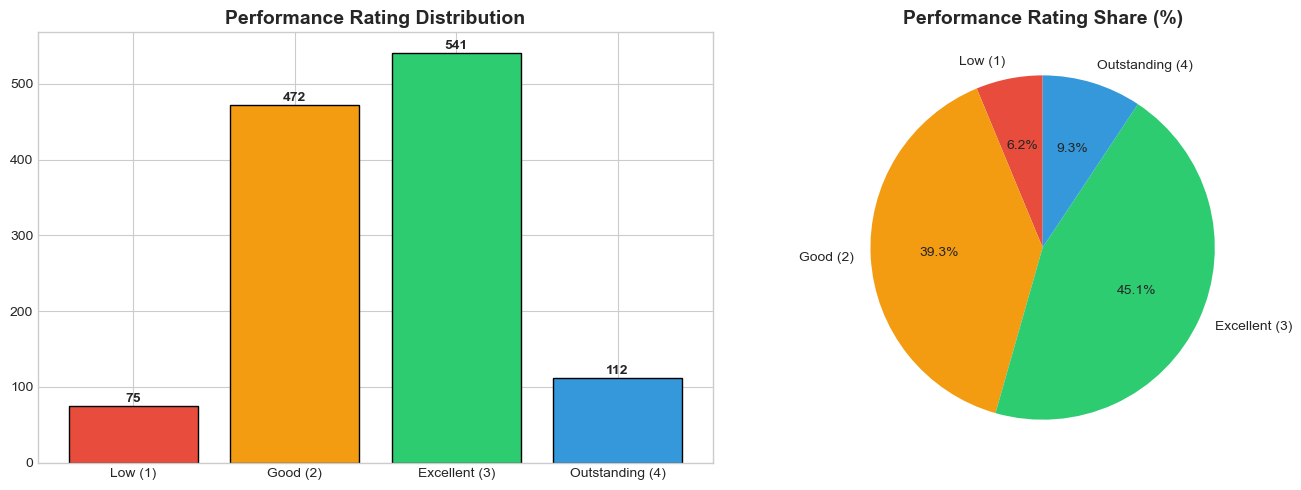

In [9]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ["Low (1)", "Good (2)", "Excellent (3)", "Outstanding (4)"]
counts = df["PerformanceRating"].value_counts().sort_index()
colors = ["#e74c3c", "#f39c12", "#2ecc71", "#3498db"]
axes[0].bar(labels, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Performance Rating Distribution", fontsize=14, fontweight="bold")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")
axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Performance Rating Share (%)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


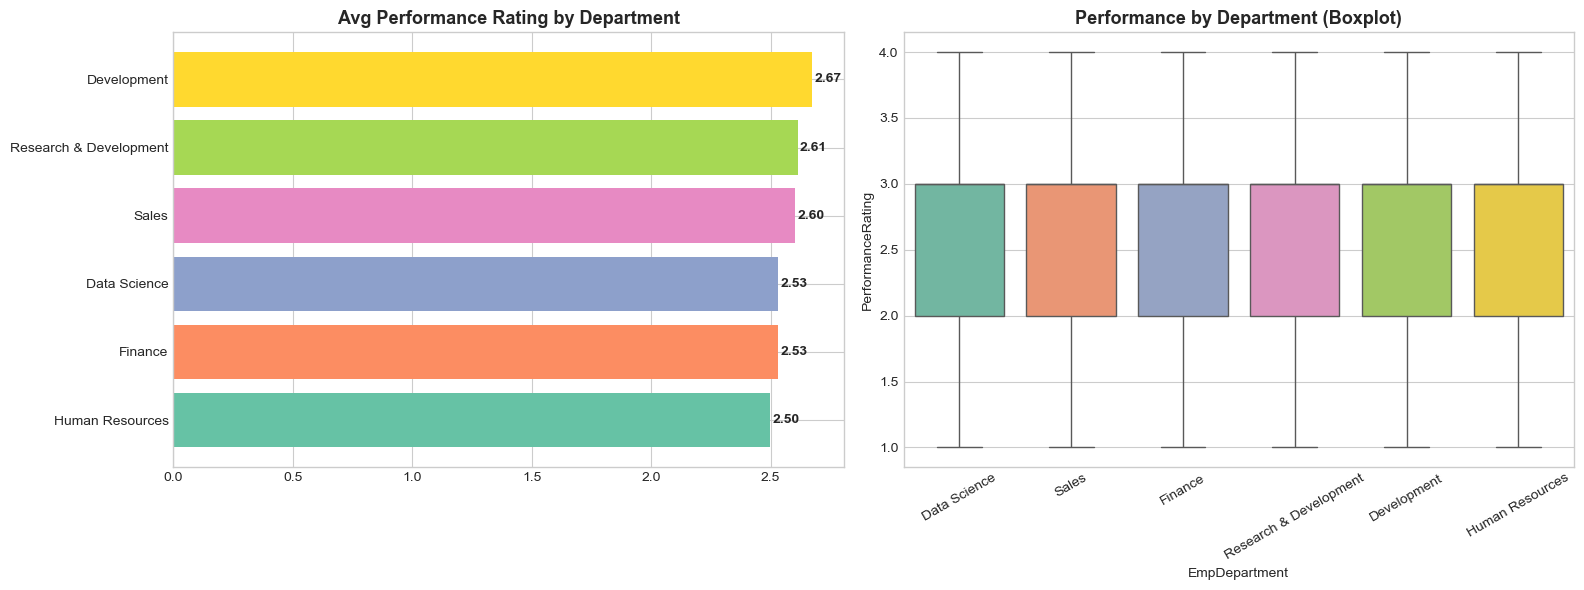

In [10]:
# Department-wise Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
dept_perf = df.groupby("EmpDepartment")["PerformanceRating"].mean().sort_values()
axes[0].barh(dept_perf.index, dept_perf.values, color=sns.color_palette("Set2", len(dept_perf)))
axes[0].set_title("Avg Performance Rating by Department", fontsize=13, fontweight="bold")
for i, v in enumerate(dept_perf.values):
    axes[0].text(v + 0.01, i, f"{v:.2f}", va="center", fontweight="bold")
sns.boxplot(data=df, x="EmpDepartment", y="PerformanceRating", palette="Set2", ax=axes[1])
axes[1].set_title("Performance by Department (Boxplot)", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("department_performance.png", dpi=150, bbox_inches="tight")
plt.show()


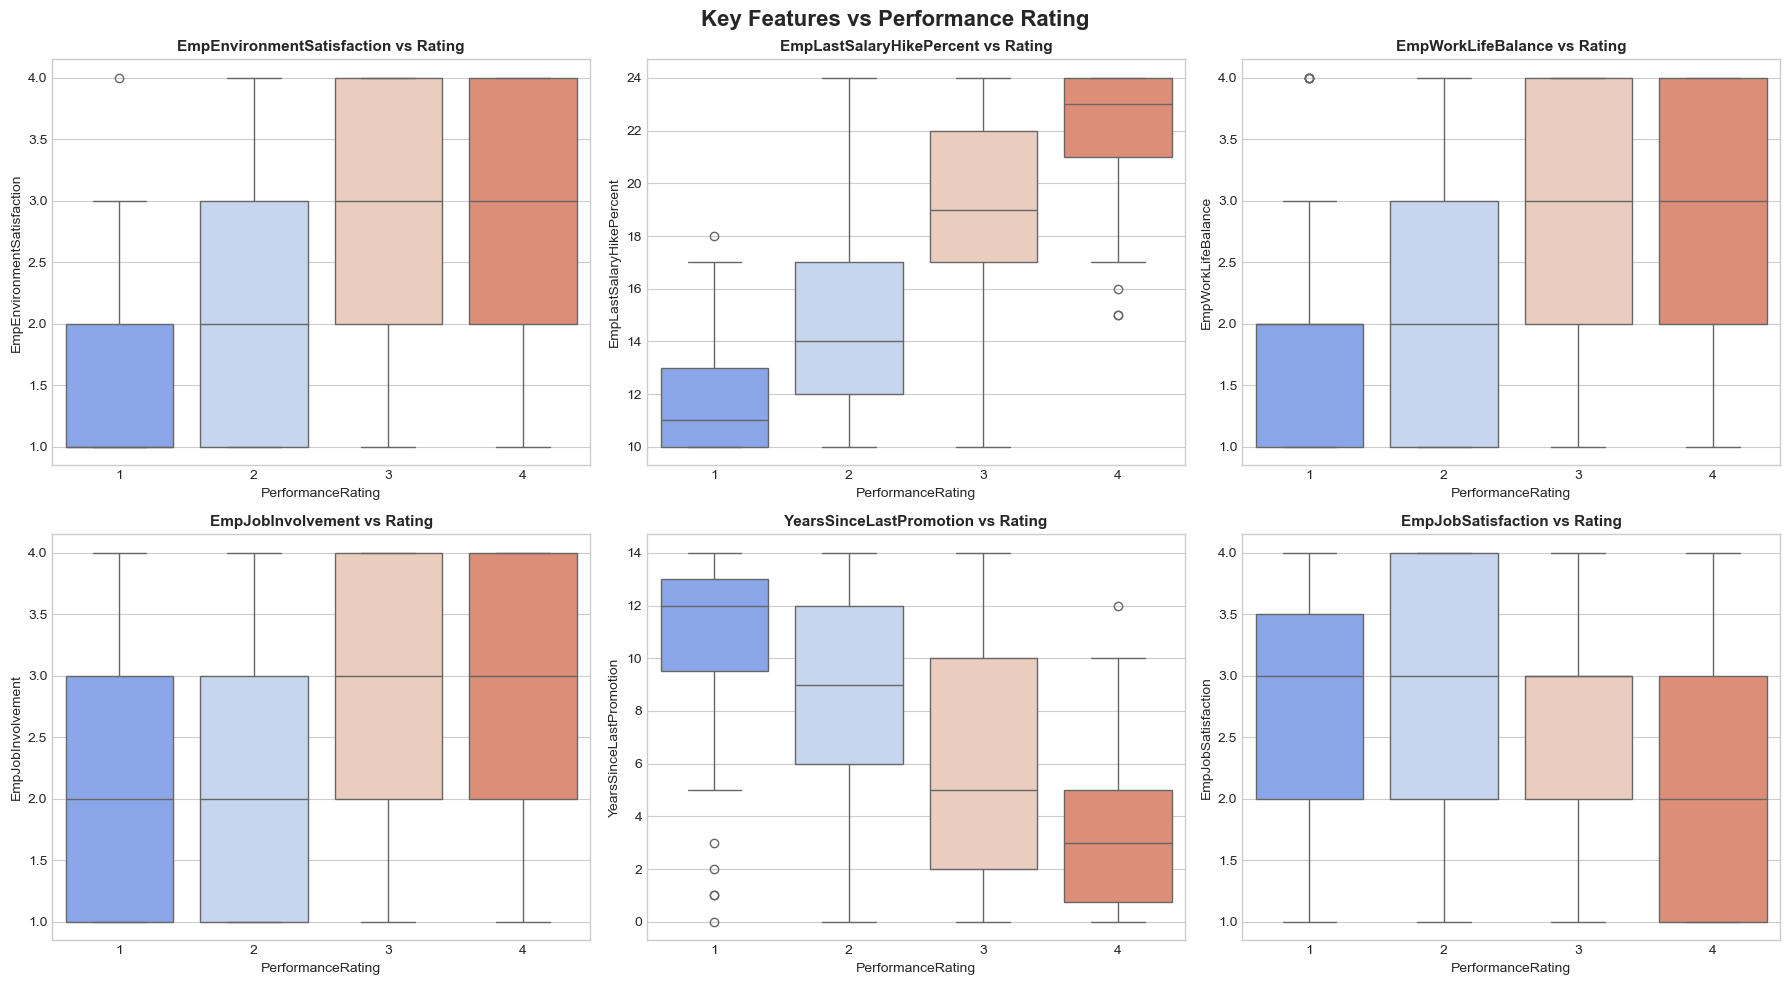

In [11]:
# Key Features vs Performance
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
key_features = ["EmpEnvironmentSatisfaction", "EmpLastSalaryHikePercent",
                "EmpWorkLifeBalance", "EmpJobInvolvement",
                "YearsSinceLastPromotion", "EmpJobSatisfaction"]
for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x="PerformanceRating", y=feat, palette="coolwarm", ax=axes[i])
    axes[i].set_title(f"{feat} vs Rating", fontsize=11, fontweight="bold")
plt.suptitle("Key Features vs Performance Rating", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("key_features.png", dpi=150, bbox_inches="tight")
plt.show()


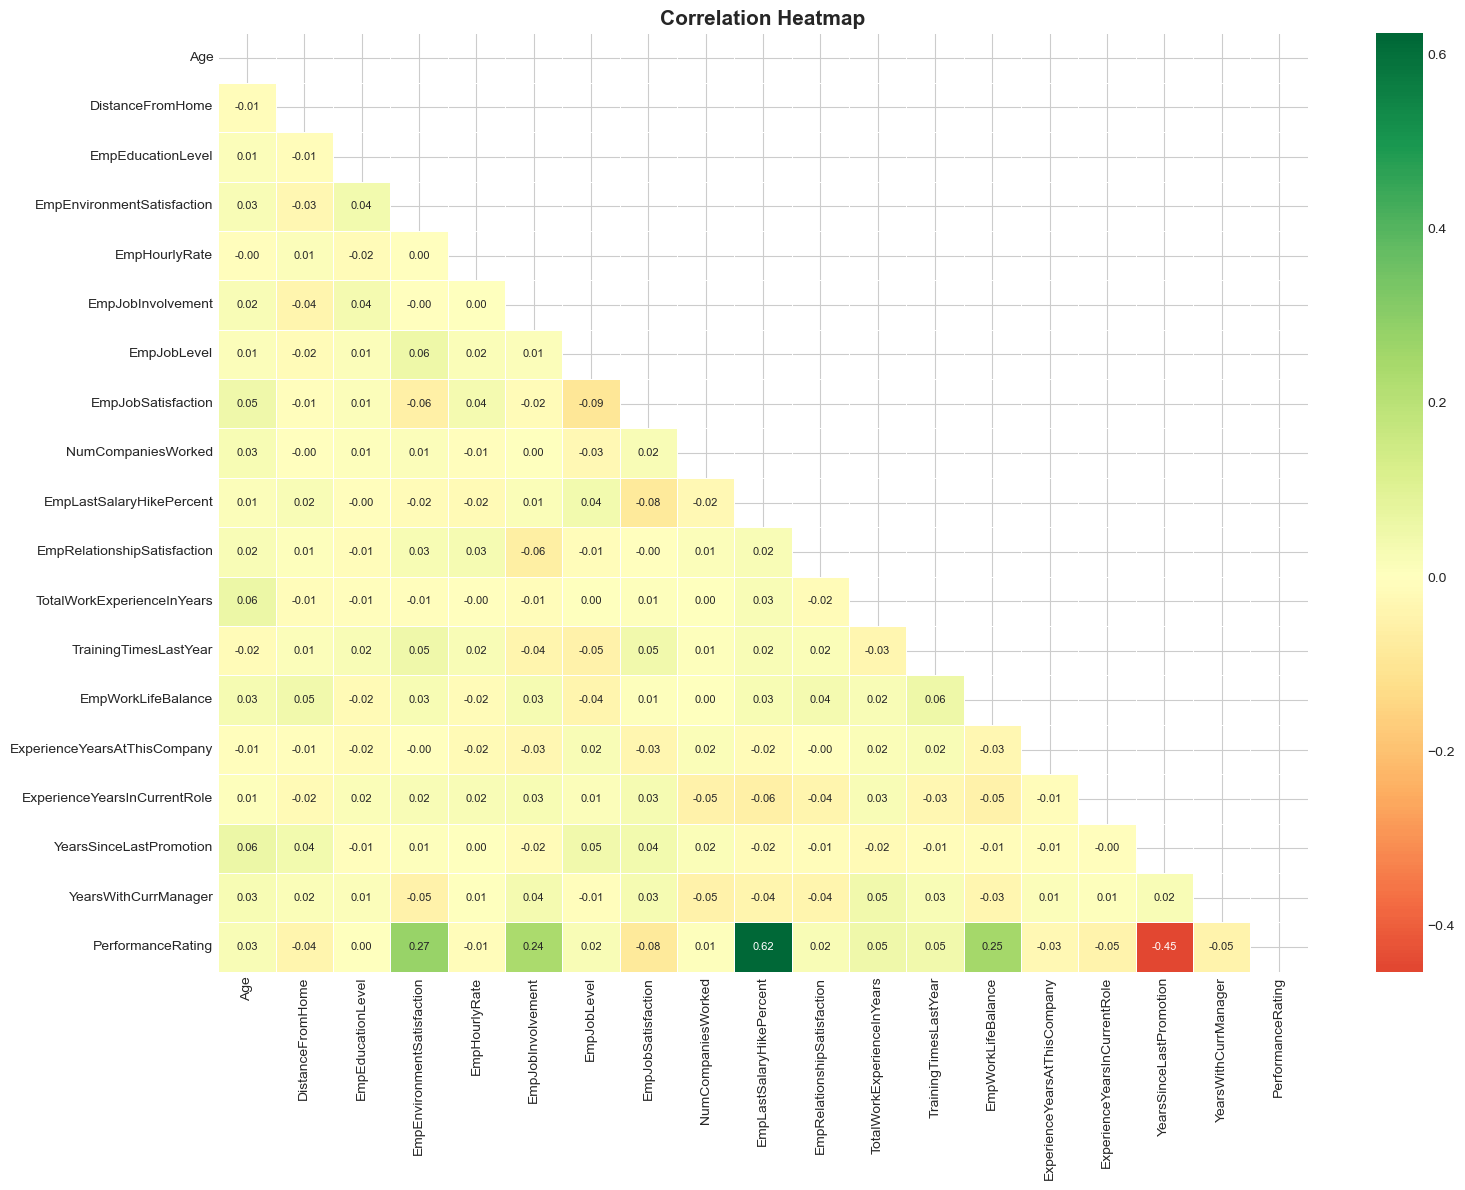

In [12]:
# Correlation Heatmap
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numerical_cols].corr()
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 5. Feature Engineering


In [13]:
df_model = df.copy()

# Label encode categorical columns
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# New feature: Average Satisfaction Score
df_model["SatisfactionScore"] = (
    df_model["EmpEnvironmentSatisfaction"] +
    df_model["EmpJobSatisfaction"] +
    df_model["EmpRelationshipSatisfaction"] +
    df_model["EmpWorkLifeBalance"]
) / 4

# New feature: Loyalty Index (company years / total experience)
df_model["LoyaltyIndex"] = (
    df_model["ExperienceYearsAtThisCompany"] /
    (df_model["TotalWorkExperienceInYears"] + 1)
)

# New feature: Promotion Gap
df_model["PromotionGap"] = (
    df_model["YearsSinceLastPromotion"] - df_model["ExperienceYearsInCurrentRole"]
)

print("Feature Engineering Complete!")
print(f"Features added: SatisfactionScore, LoyaltyIndex, PromotionGap")
print(f"Final shape: {df_model.shape}")


Feature Engineering Complete!
Features added: SatisfactionScore, LoyaltyIndex, PromotionGap
Final shape: (1200, 30)


---
## 6. Model Building


In [14]:
X = df_model.drop(columns=["PerformanceRating"])
y = df_model["PerformanceRating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")


Training set : (960, 29)
Test set     : (240, 29)


In [16]:
models = {
    "Logistic Regression"    : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"          : DecisionTreeClassifier(random_state=42),
    "Random Forest"          : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"      : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine" : SVC(kernel="rbf", random_state=42),
}

results = {}
print(f"{"Model":<28} {"Train Acc":>10} {"Test Acc":>10} {"CV Score":>15}")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_sc))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_sc))
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring="accuracy")
    results[name] = {
        "model": model, "train_acc": train_acc,
        "test_acc": test_acc, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()
    }
    print(f"{name:<28} {train_acc:>9.4f} {test_acc:>10.4f}  {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

best_name = max(results, key=lambda k: results[k]["test_acc"])
print(f"Best Model: {best_name} | Test Accuracy: {results[best_name]["test_acc"]:.4f}")


Model                         Train Acc   Test Acc        CV Score
-----------------------------------------------------------------
Logistic Regression             0.8490     0.8042  0.8104 +/- 0.0176
Decision Tree                   1.0000     0.6667  0.5969 +/- 0.0157
Random Forest                   1.0000     0.7458  0.7031 +/- 0.0342
Gradient Boosting               0.9927     0.8042  0.7479 +/- 0.0351
Support Vector Machine          0.9146     0.7417  0.7396 +/- 0.0168
Best Model: Logistic Regression | Test Accuracy: 0.8042


---
## 7. Model Evaluation


In [17]:
best_model = results[best_name]["model"]
y_pred = best_model.predict(X_test_sc)

print(f"Model: {best_name}")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=["Low (1)", "Good (2)", "Excellent (3)", "Outstanding (4)"]))


Model: Logistic Regression
                 precision    recall  f1-score   support

        Low (1)       0.62      0.67      0.65        15
       Good (2)       0.84      0.75      0.79        95
  Excellent (3)       0.79      0.91      0.84       108
Outstanding (4)       0.93      0.64      0.76        22

       accuracy                           0.80       240
      macro avg       0.80      0.74      0.76       240
   weighted avg       0.81      0.80      0.80       240



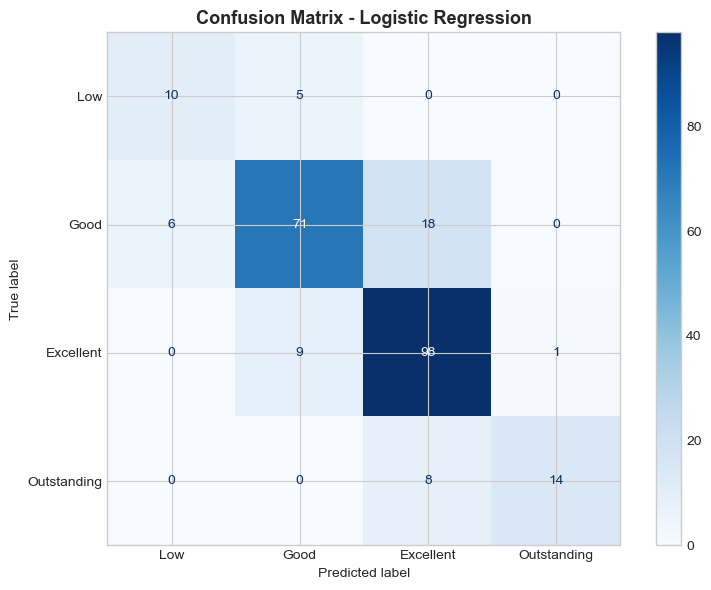

In [18]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=["Low", "Good", "Excellent", "Outstanding"])
disp.plot(ax=ax, cmap="Blues")
ax.set_title(f"Confusion Matrix - {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


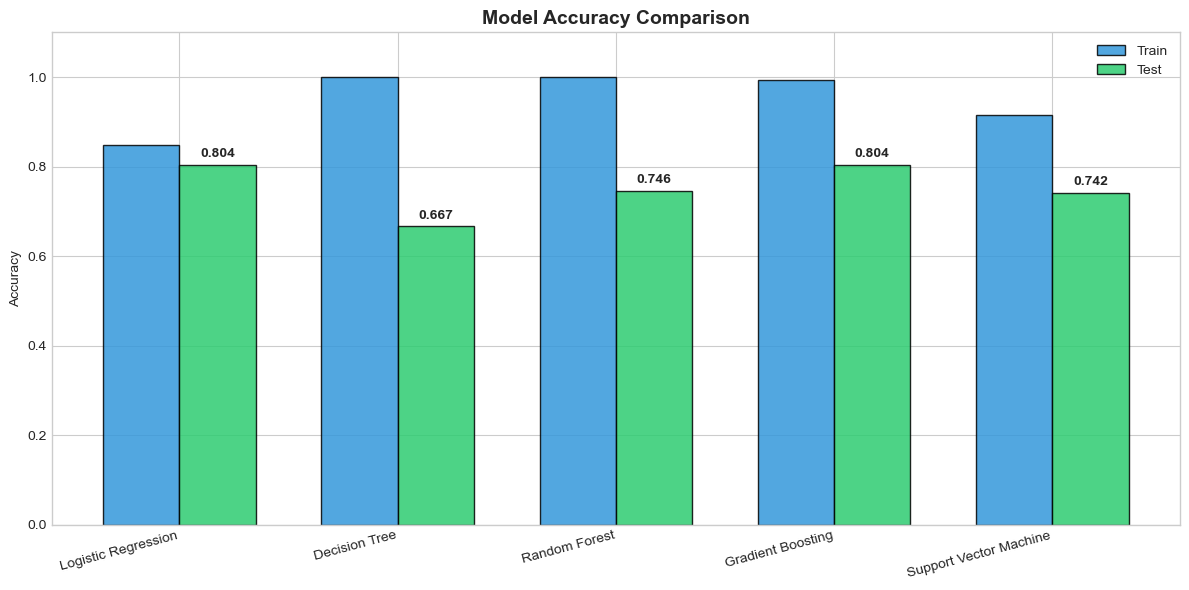

In [19]:
# Model Comparison Chart
fig, ax = plt.subplots(figsize=(12, 6))
model_names = list(results.keys())
test_accs  = [results[m]["test_acc"]  for m in model_names]
train_accs = [results[m]["train_acc"] for m in model_names]
x = np.arange(len(model_names))
width = 0.35
bars1 = ax.bar(x - width/2, train_accs, width, label="Train", color="#3498db", edgecolor="black", alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs,  width, label="Test",  color="#2ecc71", edgecolor="black", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.1)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


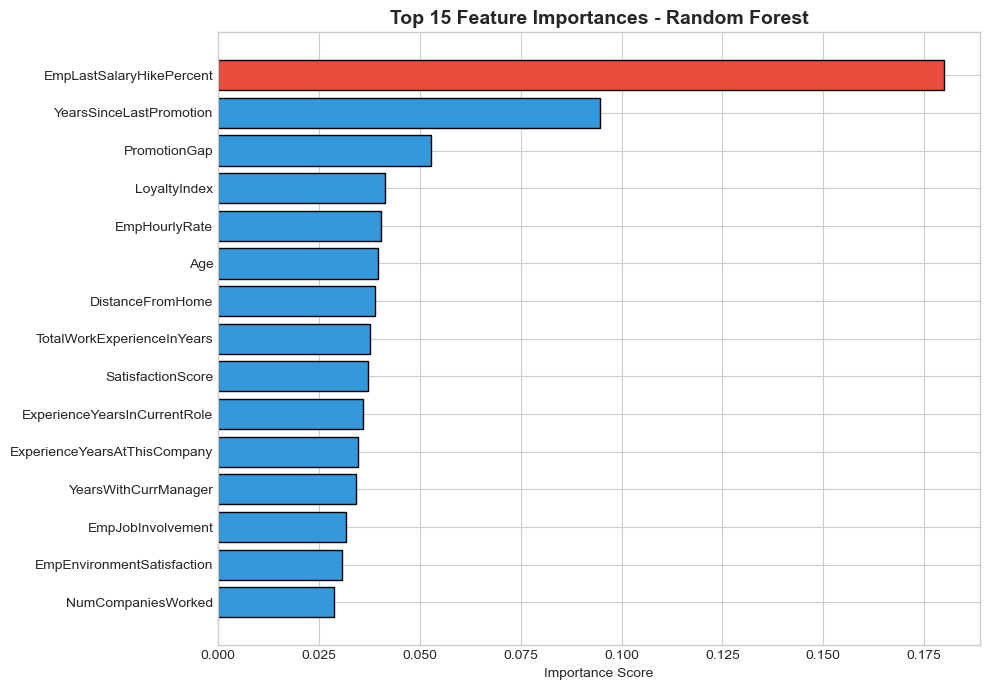

TOP 3 Most Important Features:
  1. EmpLastSalaryHikePercent: 0.1799
  2. YearsSinceLastPromotion: 0.0946
  3. PromotionGap: 0.0528


In [20]:
# Feature Importance
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if v == top_features.max() else "#3498db" for v in top_features.values]
ax.barh(top_features.index, top_features.values, color=colors, edgecolor="black")
ax.set_title("Top 15 Feature Importances - Random Forest", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("TOP 3 Most Important Features:")
for i, (feat, score) in enumerate(importances.nlargest(3).items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")


In [21]:
# Hyperparameter Tuning
param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 5],
}
print("Running GridSearchCV...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_train)
tuned_model = grid_search.best_estimator_
tuned_acc = accuracy_score(y_test, tuned_model.predict(X_test_sc))
print(f"Best Params : {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Tuned Test Accuracy: {tuned_acc:.4f}")


Running GridSearchCV...
Best Params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.7167
Tuned Test Accuracy: 0.7333


---
## 8. Conclusion & Recommendations


In [22]:
print("=" * 65)
print("        PROJECT SUMMARY")
print("=" * 65)
print(f"  Dataset   : INX Future Inc. (1,200 records, 28 features)")
print(f"  Target    : PerformanceRating (1=Low to 4=Outstanding)")
print(f"  Best Model: {best_name}")
print(f"  Test Acc  : {results[best_name]['test_acc']*100:.2f}%")
print(f"  Tuned Acc : {tuned_acc*100:.2f}%")
print()
print("  TOP 3 Factors Affecting Employee Performance:")
for i, (feat, score) in enumerate(importances.nlargest(3).items(), 1):
    print(f"  {i}. {feat} (importance: {score:.4f})")
print()
print("  BUSINESS RECOMMENDATIONS:")
print("  1. Increase salary hikes for high-performing employees")
print("  2. Improve Work Environment Satisfaction through better facilities")
print("  3. Promote Work-Life Balance via hybrid policies")
print("  4. Implement regular promotions and career growth plans")
print("  5. Rotate managers periodically to refresh team dynamics")


        PROJECT SUMMARY
  Dataset   : INX Future Inc. (1,200 records, 28 features)
  Target    : PerformanceRating (1=Low to 4=Outstanding)
  Best Model: Logistic Regression
  Test Acc  : 80.42%
  Tuned Acc : 73.33%

  TOP 3 Factors Affecting Employee Performance:
  1. EmpLastSalaryHikePercent (importance: 0.1799)
  2. YearsSinceLastPromotion (importance: 0.0946)
  3. PromotionGap (importance: 0.0528)

  BUSINESS RECOMMENDATIONS:
  1. Increase salary hikes for high-performing employees
  2. Improve Work Environment Satisfaction through better facilities
  3. Promote Work-Life Balance via hybrid policies
  4. Implement regular promotions and career growth plans
  5. Rotate managers periodically to refresh team dynamics
